In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

df_prep= pd.read_csv("cisco_firewall_preprocessed_dataset.csv")
df_prep

,model_series,cpu_util_avg,memory_util_avg,port_util_avg,interface_error_rate,connection_rate_cps,syn_flood_events,inspection_drop_rate,fragmented_packet_pct,ssl_decrypt_enabled,...,reboot_count,failover_events,core_file_count,core_file_flag,device_stability_score,severity_encoded,model_sku_A1M,model_sku_A2H,model_sku_A2L,model_sku_A2M
0,260,-1.363345,1.259906,1.289599,0.172967,-0.839855,1.336207,-1.414355,1.353863,1,...,0.362031,0.544331,1.418510,1,-0.764169,0,0,0,0,1
1,220,-0.525063,1.565812,-1.501731,-1.420899,-1.196440,-1.617057,-1.863179,-1.235555,0,...,0.362031,-0.362887,-1.994447,0,2.396785,0,0,0,0,0
2,260,1.443924,1.032255,0.288059,1.026611,-1.179300,-0.864264,-1.635027,-0.553951,0,...,-0.820110,1.451549,-0.287968,1,-0.764169,0,0,1,0,0
3,260,-0.823986,0.612523,-0.166344,1.056458,-1.365597,-0.458914,0.672674,-0.582704,1,...,-0.229040,-1.270106,0.565271,1,-0.764169,0,0,1,0,0
4,220,0.514666,0.299503,0.589448,0.363992,0.686824,1.509929,0.081723,-1.357330,0,...,-0.229040,0.544331,-0.287968,1,-0.764169,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,240,0.703117,0.470242,1.475070,-1.080635,-1.049195,-1.037985,-0.613953,-0.011036,1,...,-1.411180,0.544331,-1.141208,0,0.523024,0,0,0,0,1
76,240,1.229480,-1.073517,1.224685,-0.459803,-0.866279,0.120157,-1.795855,0.775430,1,...,-0.229040,1.451549,-0.287968,1,-0.487178,0,0,0,0,1
77,260,1.261972,-1.514590,0.473529,1.313148,0.820400,0.178064,0.137826,1.106930,1,...,-0.229040,-0.362887,1.418510,1,-0.764169,0,0,0,0,1
78,260,-0.356107,-0.354993,1.011394,-1.355234,1.529637,0.583414,0.081723,0.760208,0,...,0.362031,-0.362887,-1.141208,0,1.207354,0,1,0,0,0


UNIVARIATE ANALYSIS:

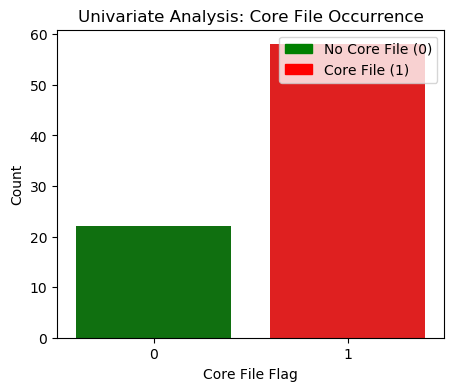

In [2]:
#Q1.Distribution of core file occurrences
plt.figure(figsize=(5,4))
colors = {0: "green", 1: "red"}  # 0 = No core file, 1 = Core file
sns.countplot(x="core_file_flag", data=df_prep, palette=[colors[0], colors[1]])

# Add legend
green_patch = mpatches.Patch(color='green', label='No Core File (0)')
red_patch = mpatches.Patch(color='red', label='Core File (1)')
plt.legend(handles=[green_patch, red_patch], loc='upper right')

plt.title("Univariate Analysis: Core File Occurrence")
plt.xlabel("Core File Flag")
plt.ylabel("Count")
plt.show()

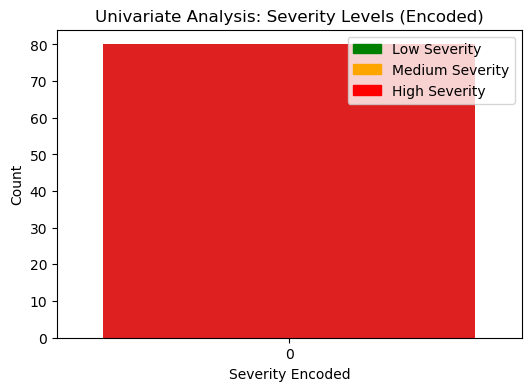

In [3]:
#Q2: Distribution of severity levels (encoded)

plt.figure(figsize=(6,4))
# severity_encoded: 0=High, 1=Low, 2=Medium (LabelEncoder)
# Remap colors for clarity
severity_colors = {0: "red", 1: "green", 2: "orange"}
sns.countplot(x="severity_encoded", data=df_prep, palette=[severity_colors[i] for i in sorted(df_prep["severity_encoded"]
                                                                                              .unique())])

# Legend for severity
red_patch = mpatches.Patch(color='red', label='High Severity')
green_patch = mpatches.Patch(color='green', label='Low Severity')
orange_patch = mpatches.Patch(color='orange', label='Medium Severity')
plt.legend(handles=[green_patch, orange_patch, red_patch], loc='upper right')

plt.title("Univariate Analysis: Severity Levels (Encoded)")
plt.xlabel("Severity Encoded")
plt.ylabel("Count")
plt.show()

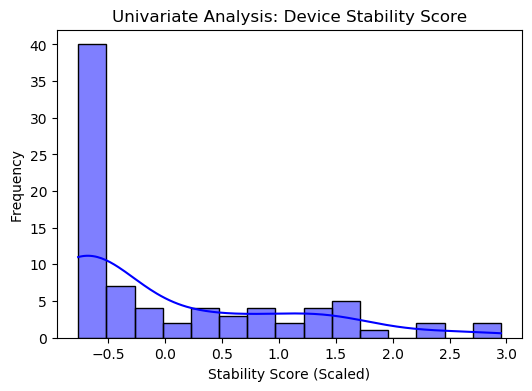

In [4]:
#Q3: Distribution of device stability scores
plt.figure(figsize=(6,4))
sns.histplot(df_prep["device_stability_score"], bins=15, kde=True, color='blue')
plt.title("Univariate Analysis: Device Stability Score")
plt.xlabel("Stability Score (Scaled)")
plt.ylabel("Frequency")
plt.show()


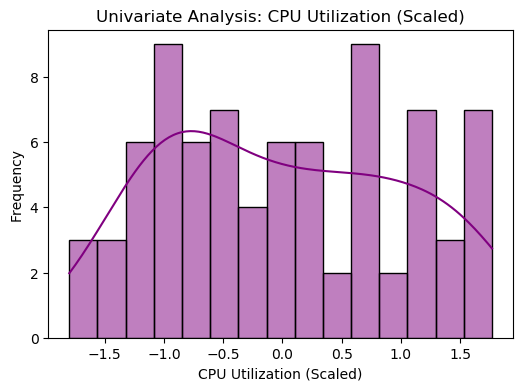

In [5]:
#Q4: Distribution of CPU utilization
plt.figure(figsize=(6,4))
sns.histplot(df_prep["cpu_util_avg"], bins=15, kde=True, color='purple')
plt.title("Univariate Analysis: CPU Utilization (Scaled)")
plt.xlabel("CPU Utilization (Scaled)")
plt.ylabel("Frequency")
plt.show()


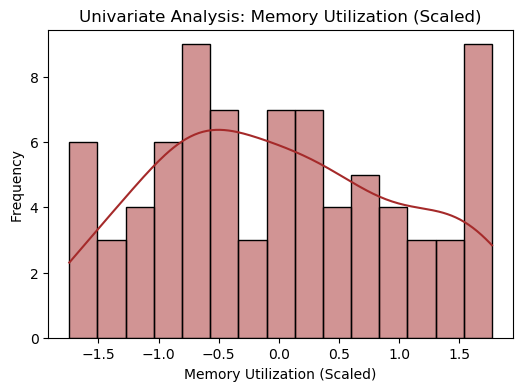

In [6]:
#Q5: Distribution of memory utilization
plt.figure(figsize=(6,4))
sns.histplot(df_prep["memory_util_avg"], bins=15, kde=True, color='brown')
plt.title("Univariate Analysis: Memory Utilization (Scaled)")
plt.xlabel("Memory Utilization (Scaled)")
plt.ylabel("Frequency")
plt.show()


BIVARIATE ANALYSIS:

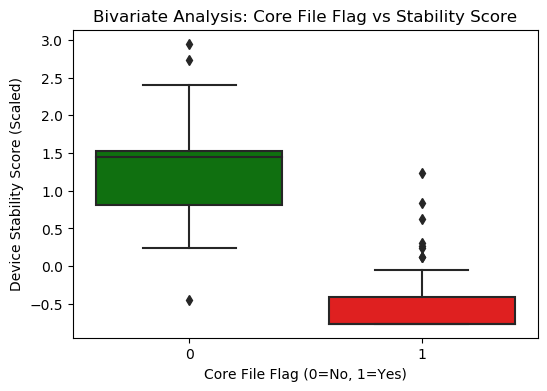

In [7]:
#Q1. How does core file occurrence relate to device stability?
plt.figure(figsize=(6,4))
sns.boxplot(x="core_file_flag", y="device_stability_score", data=df_prep, palette=["green","red"])
plt.title("Bivariate Analysis: Core File Flag vs Stability Score")
plt.xlabel("Core File Flag (0=No, 1=Yes)")
plt.ylabel("Device Stability Score (Scaled)")
plt.show()


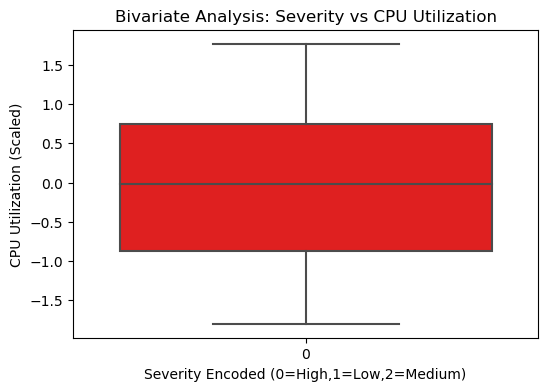

In [8]:
#Q2. How does severity relate to CPU utilization?
plt.figure(figsize=(6,4))
sns.boxplot(x="severity_encoded", y="cpu_util_avg", data=df_prep, palette=["red","green","orange"])
plt.title("Bivariate Analysis: Severity vs CPU Utilization")
plt.xlabel("Severity Encoded (0=High,1=Low,2=Medium)")
plt.ylabel("CPU Utilization (Scaled)")
plt.show()

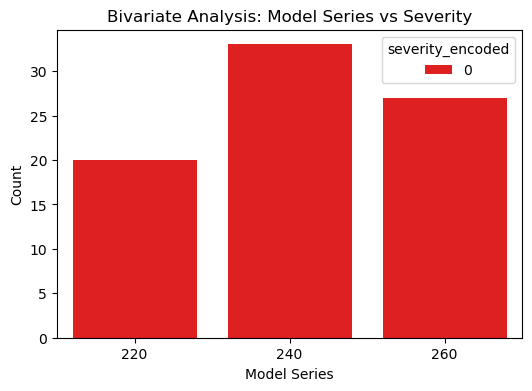

In [9]:
#Q3. How does model series relate to severity?
plt.figure(figsize=(6,4))
sns.countplot(x="model_series", hue="severity_encoded", data=df_prep, palette=["red","green","orange"])
plt.title("Bivariate Analysis: Model Series vs Severity")
plt.xlabel("Model Series")
plt.ylabel("Count")
plt.show()

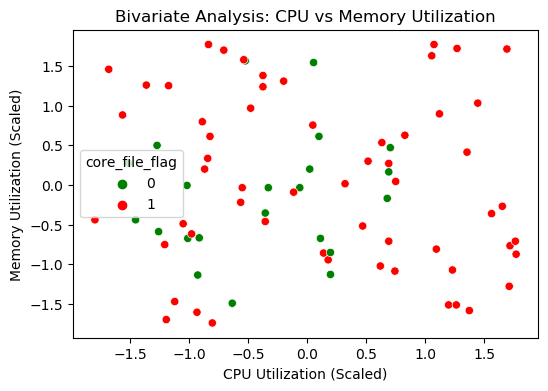

In [10]:
#Q4. Relationship between CPU and memory utilization
plt.figure(figsize=(6,4))
sns.scatterplot(x="cpu_util_avg", y="memory_util_avg", hue="core_file_flag", data=df_prep, palette=["green","red"])
plt.title("Bivariate Analysis: CPU vs Memory Utilization")
plt.xlabel("CPU Utilization (Scaled)")
plt.ylabel("Memory Utilization (Scaled)")
plt.show()

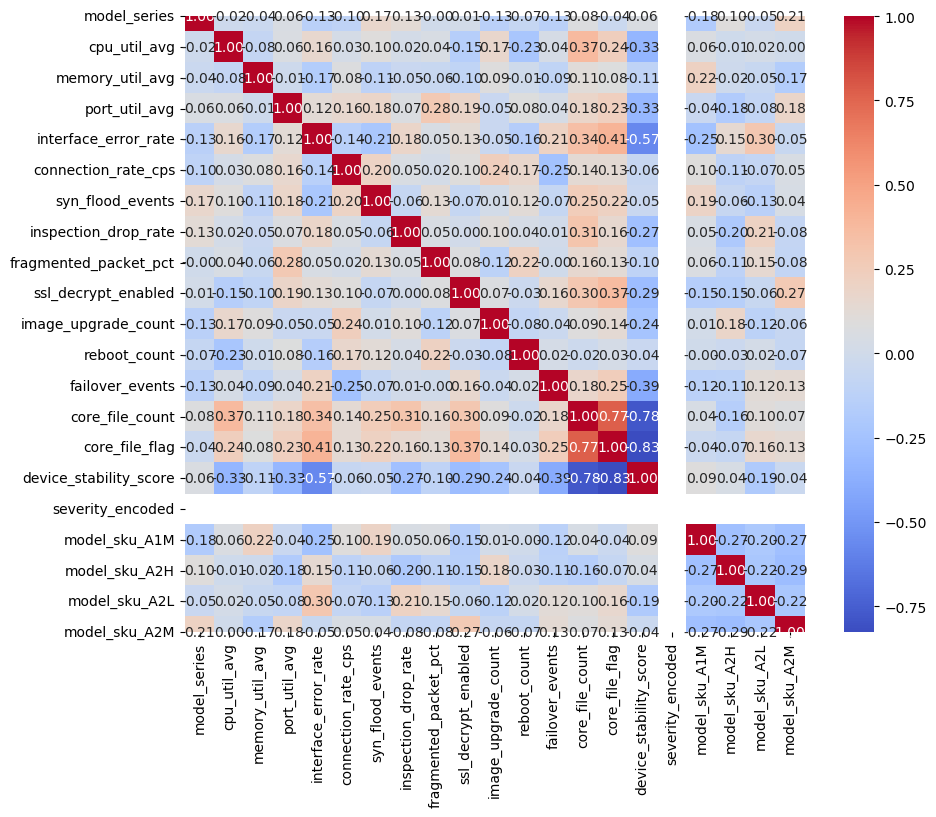

In [11]:
#Q5. HEATMAP OF CORRELATIONS

plt.figure(figsize=(10,8))
corr = df_prep.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
